# instruction fine-tuning

this notebook explores the instruction fine-tuning process

In [1]:
import inspect
import json
import math
import random
import re
import time
import urllib.request

from dataclasses import dataclass
from pathlib import Path

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers

from datasets import Dataset, DatasetDict

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

/Users/nabigchaudhry/Projects/build-llm-from-scratch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# check installed versions

print(
    "torch:",
    torch.__version__,
)

print(
    "transformers:",
    transformers.__version__,
)

print(
    "datasets:",
    datasets.__version__,
)

torch: 2.5.1
transformers: 5.17.0
datasets: 5.0.1


In [3]:
# set the random seed and device

seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.backends.mps.is_available():
    device = torch.device(
        "mps"
    )
elif torch.cuda.is_available():
    device = torch.device(
        "cuda"
    )
else:
    device = torch.device(
        "cpu"
    )

print(
    "device:",
    device,
)

device: mps


In [4]:
# store the main experimental settings

model_name = (
    "openai-community/gpt2"
)

max_length = 512

train_on_prompt = False

num_train_epochs = 3

learning_rate = 5e-5

weight_decay = 0.1

train_batch_size = 4

eval_batch_size = 4

gradient_accumulation_steps = 4

In [5]:
models_folder = Path(
    "models"
)

data_folder = Path(
    "data"
)

checkpoints_folder = (
    models_folder
    / "07_checkpoints"
)

final_model_folder = (
    models_folder
    / "07_gpt2_instruction_tuned"
)

models_folder.mkdir(
    exist_ok=True
)

data_folder.mkdir(
    exist_ok=True
)

In [6]:
# define the dataset location

data_url = (
    "https://raw.githubusercontent.com/"
    "rasbt/LLMs-from-scratch/"
    "main/ch07/01_main-chapter-code/"
    "instruction-data.json"
)

data_path = (
    data_folder
    / "instruction-data.json"
)

In [7]:
# download and load the dataset

if not data_path.exists():
    print(
        "downloading instruction data..."
    )

    urllib.request.urlretrieve(
        data_url,
        data_path,
    )

with data_path.open(
    "r",
    encoding="utf-8",
) as file:
    raw_data = json.load(
        file
    )

print(
    "number of examples:",
    len(raw_data),
)

number of examples: 1100


In [8]:
# inspect one example

example = raw_data[50]

print(
    json.dumps(
        example,
        indent=2,
    )
)

{
  "instruction": "Identify the correct spelling of the following word.",
  "input": "Ocassion",
  "output": "The correct spelling is 'Occasion.'"
}


In [9]:
# inspect an example without a seperate input

example_without_input = (
    raw_data[999]
)

print(
    json.dumps(
        example_without_input,
        indent=2,
    )
)

{
  "instruction": "What is an antonym of 'complicated'?",
  "input": "",
  "output": "An antonym of 'complicated' is 'simple'."
}


In [10]:
# create a format prompt function

def format_prompt(
    example,
):
    instruction_text = (
        "Below is an instruction that "
        "describes a task. Write a "
        "response that appropriately "
        "completes the request."
        "\n\n### Instruction:\n"
        f"{example['instruction']}"
    )

    input_text = ""

    if example["input"]:
        input_text = (
            "\n\n### Input:\n"
            f"{example['input']}"
        )

    response_header = (
        "\n\n### Response:\n"
    )

    prompt = (
        instruction_text
        + input_text
        + response_header
    )

    return prompt

In [11]:
def format_training_text(
    example,
):
    prompt = format_prompt(
        example
    )

    response = example["output"]

    training_text = (
        prompt
        + response
    )

    return training_text

In [12]:
# test the formatting functions

example = raw_data[50]

print(
    format_training_text(
        example
    )
)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [13]:
# convert the data into a hugging face dataset

full_dataset = Dataset.from_list(
    raw_data
)

print(
    full_dataset
)

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 1100
})


In [14]:
# shuffle the examples

full_dataset = full_dataset.shuffle(
    seed=seed
)

print(
    full_dataset[0]
)

{'instruction': "Translate 'How are you?' into French.", 'input': '', 'output': "The French translation of 'How are you?' is 'Comment ça va?'."}


In [15]:
# calculate the split boundaries

number_of_examples = len(
    full_dataset
)

train_end = int(
    number_of_examples
    * 0.85
)

validation_end = (
    train_end
    + int(
        number_of_examples
        * 0.05
    )
)

print(
    "total:",
    number_of_examples,
)

print(
    "training ends at:",
    train_end,
)

print(
    "validation ends at:",
    validation_end,
)

total: 1100
training ends at: 935
validation ends at: 990


In [16]:
# construct the three dataset splits

dataset = DatasetDict(
    {
        "train": full_dataset.select(
            range(
                0,
                train_end,
            )
        ),
        "validation": full_dataset.select(
            range(
                train_end,
                validation_end,
            )
        ),
        "test": full_dataset.select(
            range(
                validation_end,
                number_of_examples,
            )
        ),
    }
)

print(
    dataset
)

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 935
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 55
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 110
    })
})


In [17]:
# confirm split sizes

split_sizes = {
    split_name: len(
        split_dataset
    )
    for (
        split_name,
        split_dataset,
    ) in dataset.items()
}

print(
    split_sizes
)

{'train': 935, 'validation': 55, 'test': 110}


In [18]:
tokenizer = (
    AutoTokenizer.from_pretrained(
        model_name
    )
)

print(
    tokenizer
)

GPT2Tokenizer(name_or_path='openai-community/gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})


In [19]:
# examine gpt-2's special tokens

print(
    "end-of-text token:",
    repr(
        tokenizer.eos_token
    ),
)

print(
    "end-of-text token ID:",
    tokenizer.eos_token_id,
)

print(
    "padding token:",
    tokenizer.pad_token,
)

print(
    "padding token ID:",
    tokenizer.pad_token_id,
)

end-of-text token: '<|endoftext|>'
end-of-text token ID: 50256
padding token: None
padding token ID: None


In [20]:
# reuse end of text token as padding token

tokenizer.pad_token = (
    tokenizer.eos_token
)

tokenizer.padding_side = (
    "right"
)

print(
    "padding token:",
    repr(
        tokenizer.pad_token
    ),
)

print(
    "padding token ID:",
    tokenizer.pad_token_id,
)

padding token: '<|endoftext|>'
padding token ID: 50256


In [21]:
# load the pretrained gpt-2 model

model = (
    AutoModelForCausalLM.from_pretrained(
        model_name
    )
)

model.config.pad_token_id = (
    tokenizer.pad_token_id
)

model = model.to(
    device
)

print(
    type(
        model
    )
)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 37911.14it/s]


<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>


In [22]:
# count the total and trainable parameters

total_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)

print(
    f"total parameters: "
    f"{total_parameters:,}"
)

print(
    f"trainable parameters: "
    f"{trainable_parameters:,}"
)

total parameters: 124,439,808
trainable parameters: 124,439,808


In [23]:
# inspect token length across the training set

def count_training_tokens(
    example,
):
    training_text = (
        format_training_text(
            example
        )
        + tokenizer.eos_token
    )

    encoded = tokenizer(
        training_text,
        add_special_tokens=False,
    )

    number_of_tokens = len(
        encoded["input_ids"]
    )

    return number_of_tokens

In [24]:
# calculate length distribution

training_lengths = [
    count_training_tokens(
        example
    )
    for example
    in dataset["train"]
]

for percentile in [
    50,
    90,
    95,
    99,
    100,
]:
    token_length = np.percentile(
        training_lengths,
        percentile,
    )

    print(
        f"p{percentile}: "
        f"{token_length:.0f} tokens"
    )

p50: 56 tokens
p90: 68 tokens
p95: 72 tokens
p99: 84 tokens
p100: 92 tokens


In [25]:
# count how many examples exceed the max length

number_truncated = sum(
    length > max_length
    for length
    in training_lengths
)

print(
    "training examples longer than "
    f"{max_length}:",
    number_truncated,
)

training examples longer than 512: 0


In [26]:
# create the tokenization function

def tokenize_example(
    example,
):
    prompt = format_prompt(
        example
    )

    prompt_ids = tokenizer(
        prompt,
        add_special_tokens=False,
    )["input_ids"]

    response_text = (
        example["output"]
        + tokenizer.eos_token
    )

    response_ids = tokenizer(
        response_text,
        add_special_tokens=False,
    )["input_ids"]

    input_ids = (
        prompt_ids
        + response_ids
    )[:max_length]

    attention_mask = [
        1
    ] * len(
        input_ids
    )

    labels = input_ids.copy()

    if not train_on_prompt:
        prompt_length = min(
            len(
                prompt_ids
            ),
            len(
                labels
            ),
        )

        labels[
            :prompt_length
        ] = [
            -100
        ] * prompt_length

    if all(
        label == -100
        for label
        in labels
    ):
        raise ValueError(
            "The response was removed "
            "during truncation. Increase "
            "max_length or shorten the "
            "prompt."
        )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

In [27]:
# apply tokenization to all three splits

tokenized_dataset = dataset.map(
    tokenize_example,
    remove_columns=(
        dataset["train"].column_names
    ),
    desc=(
        "tokenizing instruction data"
    ),
)

print(
    tokenized_dataset
)

tokenizing instruction data: 100%|██████████| 110/110 [00:00<00:00, 11288.80 examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 935
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 55
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 110
    })
})


In [28]:
tokenized_example = (
    tokenized_dataset[
        "train"
    ][0]
)

original_example = (
    dataset[
        "train"
    ][0]
)

print(
    "input IDs:",
    tokenized_example[
        "input_ids"
    ][:20],
)

print(
    "labels:",
    tokenized_example[
        "labels"
    ][:20],
)

input IDs: [21106, 318, 281, 12064, 326, 8477, 257, 4876, 13, 19430, 257, 2882, 326, 20431, 32543, 262, 2581, 13, 198, 198]
labels: [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]


In [29]:
# count the scored and ignored tokens in the first example

number_of_tokens = len(
    tokenized_example[
        "input_ids"
    ]
)

number_of_scored_tokens = sum(
    label != -100
    for label
    in tokenized_example[
        "labels"
    ]
)

number_of_ignored_tokens = (
    number_of_tokens
    - number_of_scored_tokens
)

print(
    "total tokens:",
    number_of_tokens,
)

print(
    "tokens included in loss:",
    number_of_scored_tokens,
)

print(
    "tokens ignored by loss:",
    number_of_ignored_tokens,
)

total tokens: 59
tokens included in loss: 19
tokens ignored by loss: 40


In [30]:
# decode the token IDs back into text

decoded_text = tokenizer.decode(
    tokenized_example[
        "input_ids"
    ]
)

print(
    decoded_text
)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Translate 'How are you?' into French.

### Response:
The French translation of 'How are you?' is 'Comment ça va?'.<|endoftext|>


In [31]:
# display the response labels that affect loss

scored_token_ids = [
    label
    for label
    in tokenized_example[
        "labels"
    ]
    if label != -100
]

scored_text = tokenizer.decode(
    scored_token_ids
)

print(
    "reference response:"
)

print(
    original_example[
        "output"
    ]
)

print(
    "\ntext included in loss:"
)

print(
    scored_text
)

reference response:
The French translation of 'How are you?' is 'Comment ça va?'.

text included in loss:
The French translation of 'How are you?' is 'Comment ça va?'.<|endoftext|>


In [32]:
# define the custom data collator

@dataclass
class instruction_data_collator:
    pad_token_id: int
    label_pad_token_id: int = -100

    def __call__(
        self,
        features,
    ):
        batch_max_length = max(
            len(
                feature["input_ids"]
            )
            for feature
            in features
        )

        input_ids = []
        attention_masks = []
        labels = []

        for feature in features:
            padding_length = (
                batch_max_length
                - len(
                    feature["input_ids"]
                )
            )

            padded_input_ids = (
                feature["input_ids"]
                + [
                    self.pad_token_id
                ] * padding_length
            )

            padded_attention_mask = (
                feature["attention_mask"]
                + [
                    0
                ] * padding_length
            )

            padded_labels = (
                feature["labels"]
                + [
                    self.label_pad_token_id
                ] * padding_length
            )

            input_ids.append(
                padded_input_ids
            )

            attention_masks.append(
                padded_attention_mask
            )

            labels.append(
                padded_labels
            )

        return {
            "input_ids": torch.tensor(
                input_ids,
                dtype=torch.long,
            ),
            "attention_mask": torch.tensor(
                attention_masks,
                dtype=torch.long,
            ),
            "labels": torch.tensor(
                labels,
                dtype=torch.long,
            ),
        }

In [33]:
# create the data collator instance

data_collator = (
    instruction_data_collator(
        pad_token_id=(
            tokenizer.pad_token_id
        ),
    )
)

In [34]:
# select a few examples to inspect the tokenization

sample_features = [
    tokenized_dataset[
        "train"
    ][index]
    for index in range(
        3
    )
]

for (
    index,
    feature,
) in enumerate(
    sample_features
):
    print(
        f"example {index}:",
        len(
            feature[
                "input_ids"
            ]
        ),
        "tokens",
    )

example 0: 59 tokens
example 1: 63 tokens
example 2: 51 tokens


In [35]:
# apply the data collator to the sample features

sample_batch = data_collator(
    sample_features
)

In [36]:
# insepct the tensor shapes of the batch

for (
    tensor_name,
    tensor,
) in sample_batch.items():
    print(
        f"{tensor_name}:",
        tensor.shape,
        tensor.dtype,
    )

input_ids: torch.Size([3, 63]) torch.int64
attention_mask: torch.Size([3, 63]) torch.int64
labels: torch.Size([3, 63]) torch.int64


In [37]:
# decode the input IDs back into text for each example in the batch

for example_index in range(
    sample_batch[
        "input_ids"
    ].shape[0]
):
    real_token_mask = (
        sample_batch[
            "attention_mask"
        ][example_index]
        == 1
    )

    real_token_ids = (
        sample_batch[
            "input_ids"
        ][example_index][
            real_token_mask
        ]
    )

    decoded_text = tokenizer.decode(
        real_token_ids
    )

    print(
        f"\nEXAMPLE {example_index}"
    )

    print(
        decoded_text
    )

    print(
        "-" * 80
    )


EXAMPLE 0
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Translate 'How are you?' into French.

### Response:
The French translation of 'How are you?' is 'Comment ça va?'.<|endoftext|>
--------------------------------------------------------------------------------

EXAMPLE 1
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Make the first sentence a dependent clause.

### Input:
I finished my work. I went home.

### Response:
After finishing my work, I went home.<|endoftext|>
--------------------------------------------------------------------------------

EXAMPLE 2
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the opposite of 'wet'?

### Response:
The opposite of 'wet' is 'dry'.<|endoftext|>
-----------------------------------------------------------

In [38]:
# move the sample batch to the device

device_batch = {
    tensor_name: tensor.to(
        device
    )
    for (
        tensor_name,
        tensor,
    ) in sample_batch.items()
}

In [39]:
# run one forward pass through the model

model.eval()

with torch.no_grad():
    outputs = model(
        **device_batch
    )

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [40]:
print(
    type(
        outputs
    )
)

print(
    "loss:",
    outputs.loss.item(),
)

print(
    "logits shape:",
    outputs.logits.shape,
)

<class 'transformers.modeling_outputs.CausalLMOutputWithCrossAttentions'>
loss: 3.2738447189331055
logits shape: torch.Size([3, 63, 50257])


In [41]:
# select one validation example

baseline_example = (
    dataset[
        "validation"
    ][0]
)

print(
    baseline_example
)

{'instruction': 'Convert the number 10 from decimal to binary.', 'input': '', 'output': 'The binary equivalent of the decimal number 10 is 1010.'}


In [42]:
# format the generation prompt

baseline_prompt = format_prompt(
    baseline_example
)

print(
    baseline_prompt
)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the number 10 from decimal to binary.

### Response:



In [43]:
# tokenize prompt for inference

encoded_prompt = tokenizer(
    baseline_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=max_length,
)

print(
    encoded_prompt.keys()
)

print(
    "input IDs shape:",
    encoded_prompt[
        "input_ids"
    ].shape,
)

print(
    "attention mask shape:",
    encoded_prompt[
        "attention_mask"
    ].shape,
)

KeysView({'input_ids': tensor([[21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
           257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
         21017, 46486,    25,   198,  3103,  1851,   262,  1271,   838,   422,
         32465,   284, 13934,    13,   198,   198, 21017, 18261,    25,   198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])})
input IDs shape: torch.Size([1, 40])
attention mask shape: torch.Size([1, 40])


In [44]:
# move the encoded prompt to the device

print("model dtype:", next(model.parameters()).dtype)
torch.mps.synchronize()
print("model move completed successfully")

model dtype: torch.float32
model move completed successfully


In [45]:
# move the prompt tensors to the device

encoded_prompt = {
    tensor_name: tensor.to(
        device
    )
    for (
        tensor_name,
        tensor,
    ) in encoded_prompt.items()
}

In [46]:
print("model:", model.config._name_or_path)
print("class:", type(model).__name__)
print("dtype:", next(model.parameters()).dtype)
print("attention:", getattr(model.config, "_attn_implementation", "not set"))

model: openai-community/gpt2
class: GPT2LMHeadModel
dtype: torch.float32
attention: sdpa


In [47]:
model.eval()

with torch.no_grad():
    outputs = model(
        input_ids=encoded_prompt["input_ids"],
        attention_mask=encoded_prompt["attention_mask"],
        use_cache=False,
    )
    torch.mps.synchronize()

print(outputs.logits.shape)

torch.Size([1, 40, 50257])


In [83]:
# create a resuable generation function

def generate_greedy(
    model,
    encoded_prompt,
    max_new_tokens,
    eos_token_id,
):
    input_ids = encoded_prompt["input_ids"]
    attention_mask = encoded_prompt.get("attention_mask")

    model.eval()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                use_cache=False,
            )

            next_token_id = torch.argmax(
                outputs.logits[:, -1, :],
                dim=-1,
                keepdim=True,
            )

            input_ids = torch.cat(
                (input_ids, next_token_id),
                dim=1,
            )

            if attention_mask is not None:
                attention_mask = torch.cat(
                    (attention_mask, torch.ones_like(next_token_id)),
                    dim=1,
                )

            if eos_token_id is not None and (
                next_token_id == eos_token_id
            ).all():
                break

    return input_ids


def generate_response(
    model,
    example,
    max_new_tokens=100,
):
    prompt = format_prompt(example)

    encoded_prompt = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )

    encoded_prompt = {
        name: tensor.to(device)
        for name, tensor in encoded_prompt.items()
    }

    prompt_length = encoded_prompt["input_ids"].shape[1]

    generated_ids = generate_greedy(
        model=model,
        encoded_prompt=encoded_prompt,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
    )

    response_token_ids = generated_ids[0, prompt_length:]

    return tokenizer.decode(
        response_token_ids,
        skip_special_tokens=True,
    ).strip()

In [84]:
# generate responses for a few validation examples

baseline_examples = [
    dataset[
        "validation"
    ][index]
    for index in range(
        3
    )
]

In [85]:
# generate responses for the baseline examples 
# and store them in a list of dictionaries

baseline_rows = []

for (
    example_index,
    example,
) in enumerate(
    baseline_examples
):
    generated_response = (
        generate_response(
            model=model,
            example=example,
        )
    )

    baseline_rows.append(
        {
            "example_index": (
                example_index
            ),
            "instruction": (
                example[
                    "instruction"
                ]
            ),
            "input": (
                example[
                    "input"
                ]
            ),
            "reference": (
                example[
                    "output"
                ]
            ),
            "pretrained_response": (
                generated_response
            ),
        }
    )

In [86]:
baseline_results = pd.DataFrame(
    baseline_rows
)

baseline_results[
    [
        "instruction",
        "reference",
        "pretrained_response",
    ]
]

,instruction,reference,pretrained_response
0,Convert the number 10 from decimal to binary.,The binary equivalent of the decimal number 10...,10 is binary.
1,Translate 'Where is the library?' into Italian.,Dove è la biblioteca?,The Italian translation of 'Where is the libra...
2,Identify the type of triangle with angles of 9...,"A triangle with angles of 90 degrees, 45 degre...",The type of triangle with angles of 90 degrees...


In [87]:
number_of_training_examples = len(
    tokenized_dataset[
        "train"
    ]
)

physical_batches_per_epoch = (
    math.ceil(
        number_of_training_examples
        / train_batch_size
    )
)

optimizer_updates_per_epoch = (
    math.ceil(
        physical_batches_per_epoch
        / gradient_accumulation_steps
    )
)

total_optimizer_updates = (
    optimizer_updates_per_epoch
    * num_train_epochs
)

warmup_steps = math.ceil(
    total_optimizer_updates
    * 0.1
)

print(
    "training examples:",
    number_of_training_examples,
)

print(
    "physical batches per epoch:",
    physical_batches_per_epoch,
)

print(
    "optimizer updates per epoch:",
    optimizer_updates_per_epoch,
)

print(
    "total optimizer updates:",
    total_optimizer_updates,
)

print(
    "warmup steps:",
    warmup_steps,
)

training examples: 935
physical batches per epoch: 234
optimizer updates per epoch: 59
total optimizer updates: 177
warmup steps: 18


In [88]:
training_arguments = (
    TrainingArguments(
        output_dir=str(
            checkpoints_folder
        ),

        num_train_epochs=(
            num_train_epochs
        ),

        per_device_train_batch_size=(
            train_batch_size
        ),

        per_device_eval_batch_size=(
            eval_batch_size
        ),

        gradient_accumulation_steps=(
            gradient_accumulation_steps
        ),

        learning_rate=(
            learning_rate
        ),

        weight_decay=(
            weight_decay
        ),

        warmup_steps=(
            warmup_steps
        ),

        lr_scheduler_type=(
            "linear"
        ),

        max_grad_norm=1.0,

        eval_strategy=(
            "epoch"
        ),

        save_strategy=(
            "epoch"
        ),

        logging_strategy=(
            "steps"
        ),

        logging_steps=10,

        save_total_limit=2,

        load_best_model_at_end=True,

        metric_for_best_model=(
            "eval_loss"
        ),

        greater_is_better=False,

        report_to="none",

        seed=seed,

        data_seed=seed,

        dataloader_num_workers=0,

        dataloader_pin_memory=False,

        fp16=False,

        bf16=False,

        optim="adamw_torch",
    )
)

In [89]:
# create the trainer

trainer = Trainer(
    model=model,

    args=training_arguments,

    train_dataset=(
        tokenized_dataset[
            "train"
        ]
    ),

    eval_dataset=(
        tokenized_dataset[
            "validation"
        ]
    ),

    data_collator=(
        data_collator
    ),

    processing_class=(
        tokenizer
    ),
)

In [90]:
# calculate initial model loss

initial_validation_metrics = (
    trainer.evaluate()
)

print(
    initial_validation_metrics
)

Training Loss,Validation Loss,Epoch
No log,1.333324,0


{'eval_loss': 1.3333241939544678}


In [91]:
# convert initial loss to persplexity

initial_validation_loss = (
    initial_validation_metrics[
        "eval_loss"
    ]
)

initial_validation_perplexity = (
    math.exp(
        initial_validation_loss
    )
)

print(
    "initial validation loss:",
    initial_validation_loss,
)

print(
    "initial validation "
    "perplexity:",
    initial_validation_perplexity,
)

initial validation loss: 1.3333241939544678
initial validation perplexity: 3.793633223073437


In [92]:
# disable inference caching during training

model.config.use_cache = False

In [93]:
# train the model

start_time = time.time()

train_result = trainer.train()

elapsed_minutes = (
    time.time()
    - start_time
) / 60

print(
    f"training completed in "
    f"{elapsed_minutes:.2f} minutes"
)

Epoch,Training Loss,Validation Loss
1,0.837211,1.361804
2,0.687798,1.362519
3,0.572778,1.365547


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.57it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


training completed in 0.97 minutes


In [94]:
# renable inference caching after training

model.config.use_cache = True

In [95]:
# print the training metrics

print(
    train_result.metrics
)

{'train_runtime': 57.8907, 'train_samples_per_second': 48.453, 'train_steps_per_second': 3.057, 'total_flos': 94736223360000.0, 'train_loss': 0.6911348084271964, 'epoch': 3.0}


In [96]:
# identify the best checkpoint based on validation loss

print(
    "best checkpoint:",
    trainer.state.best_model_checkpoint,
)

print(
    "best validation metric:",
    trainer.state.best_metric,
)

best checkpoint: models/07_checkpoints/checkpoint-59
best validation metric: 1.3618038892745972


In [97]:
# inspect logged training history

for log_entry in (
    trainer.state.log_history
):
    print(
        log_entry
    )

{'loss': 0.9282938003540039, 'grad_norm': 9.227924346923828, 'learning_rate': 2.5e-05, 'epoch': 0.17094017094017094, 'step': 10}
{'loss': 0.8219108581542969, 'grad_norm': 8.71906566619873, 'learning_rate': 4.968553459119497e-05, 'epoch': 0.3418803418803419, 'step': 20}
{'loss': 0.8306080818176269, 'grad_norm': 12.90773868560791, 'learning_rate': 4.654088050314466e-05, 'epoch': 0.5128205128205128, 'step': 30}
{'loss': 0.7818614959716796, 'grad_norm': 9.926151275634766, 'learning_rate': 4.3396226415094345e-05, 'epoch': 0.6837606837606838, 'step': 40}
{'loss': 0.8372105598449707, 'grad_norm': 12.138875961303711, 'learning_rate': 4.025157232704403e-05, 'epoch': 0.8547008547008547, 'step': 50}
{'eval_loss': 1.3618038892745972, 'eval_model_preparation_time': 0.0002, 'eval_runtime': 0.3484, 'eval_samples_per_second': 157.883, 'eval_steps_per_second': 40.188, 'epoch': 1.0, 'step': 59}
{'loss': 0.8289735794067383, 'grad_norm': 7.919130802154541, 'learning_rate': 3.710691823899371e-05, 'epoch': 

In [98]:
# seperate training and validation logs

training_logs = [
    log_entry
    for log_entry
    in trainer.state.log_history
    if "loss" in log_entry
]

validation_logs = [
    log_entry
    for log_entry
    in trainer.state.log_history
    if "eval_loss" in log_entry
]

print(
    "number of training logs:",
    len(
        training_logs
    ),
)

print(
    "number of validation logs:",
    len(
        validation_logs
    ),
)

number of training logs: 17
number of validation logs: 3


In [99]:
# extract the steps and losses

training_steps = [
    log_entry[
        "step"
    ]
    for log_entry
    in training_logs
]

training_losses = [
    log_entry[
        "loss"
    ]
    for log_entry
    in training_logs
]

validation_steps = [
    log_entry[
        "step"
    ]
    for log_entry
    in validation_logs
]

validation_losses = [
    log_entry[
        "eval_loss"
    ]
    for log_entry
    in validation_logs
]

print(
    "training steps:",
    training_steps,
)

print(
    "training losses:",
    training_losses,
)

print(
    "validation steps:",
    validation_steps,
)

print(
    "validation losses:",
    validation_losses,
)

training steps: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170]
training losses: [0.9282938003540039, 0.8219108581542969, 0.8306080818176269, 0.7818614959716796, 0.8372105598449707, 0.8289735794067383, 0.638089656829834, 0.6194921016693116, 0.5510741233825683, 0.6596001625061035, 0.6877981185913086, 0.682470178604126, 0.5268778324127197, 0.6034719467163085, 0.5044430255889892, 0.6702371597290039, 0.5727783679962158]
validation steps: [59, 118, 177]
validation losses: [1.3618038892745972, 1.3625186681747437, 1.3655472993850708]


In [100]:
# extract the steps and losses

training_steps = [
    log_entry[
        "step"
    ]
    for log_entry
    in training_logs
]

training_losses = [
    log_entry[
        "loss"
    ]
    for log_entry
    in training_logs
]

validation_steps = [
    log_entry[
        "step"
    ]
    for log_entry
    in validation_logs
]

validation_losses = [
    log_entry[
        "eval_loss"
    ]
    for log_entry
    in validation_logs
]

print(
    "training steps:",
    training_steps,
)

print(
    "training losses:",
    training_losses,
)

print(
    "validation steps:",
    validation_steps,
)

print(
    "validation losses:",
    validation_losses,
)

training steps: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170]
training losses: [0.9282938003540039, 0.8219108581542969, 0.8306080818176269, 0.7818614959716796, 0.8372105598449707, 0.8289735794067383, 0.638089656829834, 0.6194921016693116, 0.5510741233825683, 0.6596001625061035, 0.6877981185913086, 0.682470178604126, 0.5268778324127197, 0.6034719467163085, 0.5044430255889892, 0.6702371597290039, 0.5727783679962158]
validation steps: [59, 118, 177]
validation losses: [1.3618038892745972, 1.3625186681747437, 1.3655472993850708]


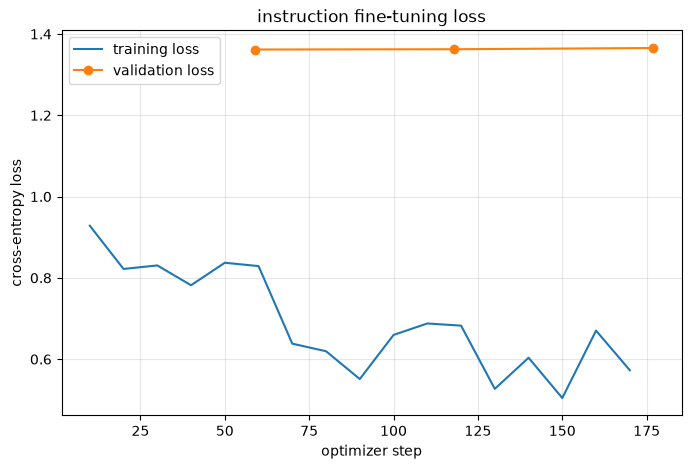

In [101]:
# plot the learning curves

plt.figure(
    figsize=(
        8,
        5,
    )
)

plt.plot(
    training_steps,
    training_losses,
    label="training loss",
)

plt.plot(
    validation_steps,
    validation_losses,
    marker="o",
    label="validation loss",
)

plt.xlabel(
    "optimizer step"
)

plt.ylabel(
    "cross-entropy loss"
)

plt.title(
    "instruction fine-tuning loss"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()

In [102]:
# evaluate the validation set

validation_metrics = (
    trainer.evaluate(
        eval_dataset=(
            tokenized_dataset[
                "validation"
            ]
        ),
        metric_key_prefix=(
            "validation"
        ),
    )
)

print(
    validation_metrics
)

Training Loss,Validation Loss,Epoch
0.572778,1.361804,3


{'validation_loss': 1.3618038892745972}


In [103]:
# evaluate the test set

test_metrics = (
    trainer.evaluate(
        eval_dataset=(
            tokenized_dataset[
                "test"
            ]
        ),
        metric_key_prefix=(
            "test"
        ),
    )
)

print(
    test_metrics
)

Training Loss,Validation Loss,Epoch
0.572778,1.213712,3


{'test_loss': 1.2137123346328735}


In [104]:
# convert the validation and test losses to perplexity

validation_loss = (
    validation_metrics[
        "validation_loss"
    ]
)

test_loss = (
    test_metrics[
        "test_loss"
    ]
)

validation_perplexity = math.exp(
    validation_loss
)

test_perplexity = math.exp(
    test_loss
)

print(
    "validation loss:",
    validation_loss,
)

print(
    "validation perplexity:",
    validation_perplexity,
)

print(
    "test loss:",
    test_loss,
)

print(
    "test perplexity:",
    test_perplexity,
)

validation loss: 1.3618038892745972
validation perplexity: 3.9032279460561763
test loss: 1.2137123346328735
test perplexity: 3.3659570462911663


In [105]:
# compare generation before and after fine-tuning

fine_tuned_responses = []

for example in baseline_examples:
    generated_response = (
        generate_response(
            model=model,
            example=example,
        )
    )

    fine_tuned_responses.append(
        generated_response
    )

baseline_results[
    "fine_tuned_response"
] = fine_tuned_responses

In [106]:
# display the before- and after-fine-tuning responses

baseline_results[
    [
        "instruction",
        "input",
        "reference",
        "pretrained_response",
        "fine_tuned_response",
    ]
]

,instruction,input,reference,pretrained_response,fine_tuned_response
0,Convert the number 10 from decimal to binary.,,The binary equivalent of the decimal number 10...,10 is binary.,The binary number 10 is 10.
1,Translate 'Where is the library?' into Italian.,,Dove è la biblioteca?,The Italian translation of 'Where is the libra...,The Italian translation of 'Where is the libra...
2,Identify the type of triangle with angles of 9...,,"A triangle with angles of 90 degrees, 45 degre...",The type of triangle with angles of 90 degrees...,The type of triangle is a triangle with a radi...


In [107]:
# define text normalization

def normalize_text(
    text,
):
    normalized_text = (
        text
        .lower()
        .strip()
    )

    normalized_text = re.sub(
        r"\s+",
        " ",
        normalized_text,
    )

    normalized_text = re.sub(
        r"[^a-z0-9\s]",
        "",
        normalized_text,
    )

    return normalized_text

In [108]:
# define token-overlap f1

from collections import Counter


def token_f1_score(
    prediction,
    reference,
):
    prediction_tokens = (
        normalize_text(
            prediction
        )
        .split()
    )

    reference_tokens = (
        normalize_text(
            reference
        )
        .split()
    )

    if (
        not prediction_tokens
        and not reference_tokens
    ):
        return 1.0

    if (
        not prediction_tokens
        or not reference_tokens
    ):
        return 0.0

    prediction_counts = Counter(
        prediction_tokens
    )

    reference_counts = Counter(
        reference_tokens
    )

    shared_counts = (
        prediction_counts
        & reference_counts
    )

    number_of_shared_tokens = sum(
        shared_counts.values()
    )

    precision = (
        number_of_shared_tokens
        / len(
            prediction_tokens
        )
    )

    recall = (
        number_of_shared_tokens
        / len(
            reference_tokens
        )
    )

    if (
        precision
        + recall
        == 0
    ):
        return 0.0

    f1 = (
        2
        * precision
        * recall
        / (
            precision
            + recall
        )
    )

    return f1

In [109]:
# generate test examples

evaluation_sample_size = min(
    20,
    len(
        dataset[
            "test"
        ]
    ),
)

print(
    "examples to generate:",
    evaluation_sample_size,
)

examples to generate: 20


In [110]:
# generate held-out responses

evaluation_rows = []

for example_index in range(
    evaluation_sample_size
):
    example = dataset[
        "test"
    ][example_index]

    prediction = generate_response(
        model=model,
        example=example,
    )

    reference = example[
        "output"
    ]

    normalized_prediction = (
        normalize_text(
            prediction
        )
    )

    normalized_reference = (
        normalize_text(
            reference
        )
    )

    exact_match = (
        normalized_prediction
        == normalized_reference
    )

    token_f1 = token_f1_score(
        prediction=prediction,
        reference=reference,
    )

    evaluation_rows.append(
        {
            "example_index": (
                example_index
            ),
            "instruction": (
                example[
                    "instruction"
                ]
            ),
            "input": (
                example[
                    "input"
                ]
            ),
            "reference": (
                reference
            ),
            "prediction": (
                prediction
            ),
            "exact_match": (
                exact_match
            ),
            "token_f1": (
                token_f1
            ),
        }
    )

In [111]:
# convert results to table

generation_results = pd.DataFrame(
    evaluation_rows
)

generation_results[
    [
        "instruction",
        "reference",
        "prediction",
        "exact_match",
        "token_f1",
    ]
].head(
    10
)

,instruction,reference,prediction,exact_match,token_f1
0,Name three essential vitamins for human health.,1. Vitamin A\n2. Vitamin C\n3. Vitamin D,1. Vitamin B12\n2. Vitamin B12 deficiency\n3. ...,False,0.500000
1,Rewrite the following sentence to include a pe...,"The wind howls with might today, as if declari...",The wind is strong today.,False,0.375000
2,Rewrite the sentence using a simile.,She is as graceful as a swan.,She is as graceful as a lion.,False,0.857143
3,Rewrite the sentence using an idiom.,He has a stroke of luck.,He is so lucky that he can achieve anything.,False,0.133333
4,What is a synonym for 'large'?,A synonym for 'large' is 'big'.,A synonym for 'large' is 'small'.,False,0.833333
5,What is the pH of lemon juice?,The pH of lemon juice is approximately 2.0.,The pH of lemon juice is typically around 7.,False,0.705882
6,What is the opposite of the adjective 'generous'?,The opposite of 'generous' is 'stingy' or 'mis...,The opposite of the adjective 'generous' is 'w...,False,0.625000
7,What type of number is 0?,0 is an integer.,The type of number is 0.,False,0.400000
8,What is the square root of 64?,The square root of 64 is 8.,The square root of 64 is 2.,False,0.857143
9,Create a sentence using the word 'nostalgia'.,Nostalgia washed over her as she looked throug...,The nostalgia for the past is strong.,False,0.222222
